# Mounting and Matting Prints: A Pedagogical Guide

After you have spent hours perfecting a photograph in the darkroom, the final step is presentation. The main function of a mount is to isolate your print, clearing the immediate surroundings of visual distractions so the viewer can focus entirely on the image. Furthermore, proper matting provides your print with a safe, protective environment that can help it last a lifetime. 

Let's start by defining the basic components of a properly presented print:
1. **The Mount-Board:** The sturdy back foundation your photograph is attached to.
2. **The Print:** Your actual photograph.
3. **The Overmat (Window Mat):** A board with a window cut out of it that sits on top of the print and protects it from touching the frame's glass.
4. **The Backboard:** An extra layer behind the mount-board to give the whole assembly rigidity inside a frame.

Let's set up a simple Python class to represent these physical components.

In [1]:
class MattedPrint:
    def __init__(self, print_width, print_height, board_width, board_height):
        self.print_w = print_width
        self.print_h = print_height
        self.board_w = board_width
        self.board_h = board_height
        
    def summary(self):
        print("--- Presentation Layers ---")
        print("1. Overmat (Top layer, frames the print)")
        print(f"2. Print ({self.print_w}x{self.print_h} inches)")
        print(f"3. Mount-Board ({self.board_w}x{self.board_h} inches)")
        print("4. Backboard (Provides rigidity in the frame)")

# Let's create an 8x10 print on an 16x20 board
my_artwork = MattedPrint(8, 10, 16, 20)
my_artwork.summary()

--- Presentation Layers ---
1. Overmat (Top layer, frames the print)
2. Print (8x10 inches)
3. Mount-Board (16x20 inches)
4. Backboard (Provides rigidity in the frame)


## Choosing Your Materials and Colors

If you want your print to survive the test of time, you must be careful about the materials you use. Standard illustration board is made of wood pulp containing acids and lignin. Over time, these chemicals will burn into your photograph and turn the board yellow. 

Instead, you should choose one of these archival options:
* **Museum Board (Cotton-rag board):** Made of 100% cotton fibers, this is naturally acid-free and lignin-free, offering the highest level of protection.
* **Conservation Board:** Made of wood pulp that has been chemically treated to eliminate acid and lignin.

When choosing a color for your board, it is generally best to avoid pure black or stark white. An off-white or ivory board that is slightly darker than the paper-white of your photograph will create an optical illusion that makes your print's highlights appear brighter and more brilliant.

## Attachment Methods: Permanent vs. Reversible

How you attach the print to the mount-board depends on whether you want the process to be permanent.

**1. Dry-Mounting (Permanent):** This technique uses a thin sheet of heat-activated adhesive (dry-mount tissue) placed between the print and the mount-board. A heated dry-mount press melts the tissue, creating a perfectly flat, permanent bond.

**2. Hinge or Corner Mounting (Reversible):**
Many galleries prefer prints that can be removed and reframed easily. To do this, you can use acid-free, water-soluble tape to create a "hinge" at the top of the print, or use folded acid-free paper to create little "pockets" for the corners of the photograph.

## Calculating the "Optical Center"

When deciding how wide to make your borders, 3 to 4 inches is a good standard minimum. 

However, you should **never** place your print exactly in the vertical center of the board. The human eye suffers from an optical illusion where a perfectly centered image appears to be sagging downward toward the bottom edge. 

To fix this illusion, we use the "Optical Center" rule:
* The left and right borders should be equal.
* The top border is usually equal to the side borders.
* The bottom border must *always* be larger than the top border to anchor the image.

Let's write some code to calculate the Optical Center and visualize what this actually looks like when cutting your mat.


--- Cutting Guide ---
Side Borders: 4.0 inches
Top Border: 4.0 inches
Bottom Border: 6.0 inches


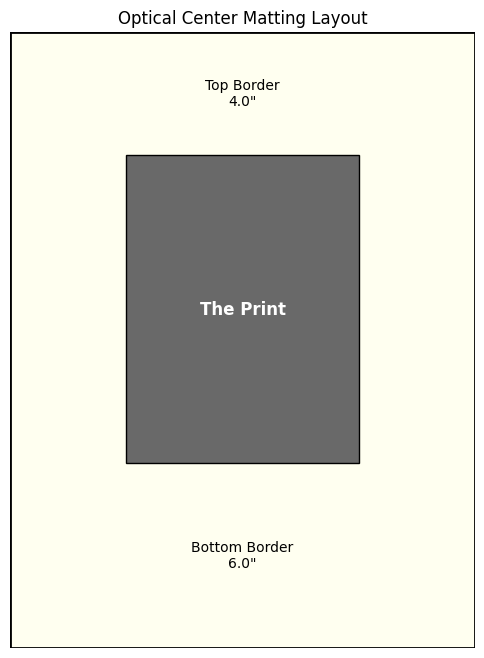

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class MattedPrintVisualizer(MattedPrint):
    def calculate_borders(self):
        # Left and Right borders are equal
        self.side_border = (self.board_w - self.print_w) / 2
        
        # For the optical center, we make the top border equal to the side border.
        # The remaining space goes to the bottom border, making it the thickest.
        self.top_border = self.side_border
        self.bottom_border = self.board_h - self.print_h - self.top_border
        
        print("\n--- Cutting Guide ---")
        print(f"Side Borders: {self.side_border} inches")
        print(f"Top Border: {self.top_border} inches")
        print(f"Bottom Border: {self.bottom_border} inches")

    def draw(self):
        fig, ax = plt.subplots(figsize=(6, 8))
        
        # Draw the off-white Mount Board
        board = patches.Rectangle((0, 0), self.board_w, self.board_h, 
                                  linewidth=2, edgecolor='black', facecolor='ivory')
        ax.add_patch(board)
        
        # Draw the Print (placed using the bottom and side border coordinates)
        print_rect = patches.Rectangle((self.side_border, self.bottom_border), 
                                       self.print_w, self.print_h, 
                                       linewidth=1, edgecolor='black', facecolor='dimgray')
        ax.add_patch(print_rect)
        
        # Add labels
        plt.text(self.board_w/2, self.bottom_border + self.print_h/2, 'The Print', 
                 color='white', ha='center', va='center', fontsize=12, fontweight='bold')
        
        plt.text(self.board_w/2, self.bottom_border / 2, f'Bottom Border\n{self.bottom_border}"', 
                 ha='center', va='center', fontsize=10)
                 
        plt.text(self.board_w/2, self.board_h - (self.top_border / 2), f'Top Border\n{self.top_border}"', 
                 ha='center', va='center', fontsize=10)

        ax.set_xlim(0, self.board_w)
        ax.set_ylim(0, self.board_h)
        ax.axis('off')
        plt.title("Optical Center Matting Layout")
        plt.show()

# Run the visualization for an 8x10 print on a 16x20 board
visualizer = MattedPrintVisualizer(8, 10, 16, 20)
visualizer.calculate_borders()
visualizer.draw()